# TT-06 - Naive Bayes - Loc tin nhan rac cho tong dai vien thong

Muc tieu: PRECISION >= 0,98 (chap nhan recall thap hon), vi chan nham tin
that (co the chua ma OTP) nghiem trong hon la lot mot vai tin rac.

In [1]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, precision_recall_curve,
)

RANDOM_STATE = 42

## 1. Nap du lieu
File goc encoding la latin-1, doc bang utf-8 se bi UnicodeDecodeError.

In [2]:
df = pd.read_csv("../spam.csv", encoding="latin-1")
df = df[["v1", "v2"]].rename(columns={"v1": "label", "v2": "text"})
print(f"Du lieu goc: {df.shape[0]} dong")
df.head()

Du lieu goc: 5572 dong


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Loai tin nhan trung lap
Bo du lieu nay co khoang 400 dong trung, neu de nguyen se ro ri giua
train/test (cung mot tin xuat hien ca hai tap).

In [3]:
n_dup = df.duplicated(subset=["label", "text"]).sum()
df = df.drop_duplicates(subset=["label", "text"]).reset_index(drop=True)
print(f"Da loai {n_dup} dong trung lap -> con {df.shape[0]} dong")

y = (df["label"] == "spam").astype(int)
df["label"].value_counts(normalize=True).round(3)

Da loai 403 dong trung lap -> con 5169 dong


label
ham     0.874
spam    0.126
Name: proportion, dtype: float64

## 3. EDA - do dai tin nham vs spam
Gia thuyet: tin spam thuong dai hon (nhieu link, dieu khoan, so dien thoai).

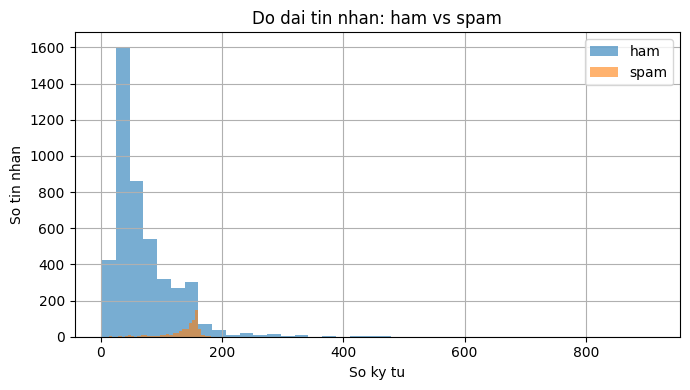

label
ham      70.5
spam    137.9
Name: n_chars, dtype: float64


In [4]:
df["n_chars"] = df["text"].str.len()

fig, ax = plt.subplots(figsize=(7, 4))
df[df.label == "ham"]["n_chars"].hist(bins=40, alpha=0.6, label="ham", ax=ax)
df[df.label == "spam"]["n_chars"].hist(bins=40, alpha=0.6, label="spam", ax=ax)
ax.set_xlabel("So ky tu")
ax.set_ylabel("So tin nhan")
ax.set_title("Do dai tin nhan: ham vs spam")
ax.legend()
fig.tight_layout()
fig.savefig("../reports/do_dai_tin.png", dpi=120)
plt.show()

print(df.groupby("label")["n_chars"].mean().round(1))

Dung nhu du doan: spam dai hon ham gan gap doi. Do dai co the dung nhu
mot dac trung phu, nhung minh se chi dung noi dung van ban qua vectorizer
cho don gian truoc, vi vector hoa da nam bat duoc dieu nay gian tiep.

## Chia train/test
Chia TRUOC khi vector hoa de tranh ro ri tu vung / IDF tu tap test.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

## 4. Baseline - DummyClassifier
Vi du lieu mat can bang (87% ham), accuracy khong noi len dieu gi ca.

In [6]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print(f"Baseline accuracy: {dummy.score(X_test, y_test):.4f} (vo dung, luon doan ham)")

Baseline accuracy: 0.8733 (vo dung, luon doan ham)


## 5-7. So sanh 3 to hop: Count+Multinomial / TF-IDF+Multinomial / TF-IDF+Bernoulli

In [7]:
combos = {
    "Count + MultinomialNB": make_pipeline(
        CountVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.9),
        MultinomialNB(alpha=0.1),
    ),
    "TF-IDF + MultinomialNB": make_pipeline(
        TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True),
        MultinomialNB(alpha=0.1),
    ),
    "TF-IDF + BernoulliNB": make_pipeline(
        TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True),
        BernoulliNB(alpha=0.1),
    ),
}

rows = []
for name, pipe in combos.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        "to_hop": name,
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "accuracy": accuracy_score(y_test, pred),
    })

result_table = pd.DataFrame(rows).sort_values("f1", ascending=False)
result_table.round(4)

,to_hop,precision,recall,f1,accuracy
1,TF-IDF + MultinomialNB,0.9833,0.9008,0.9402,0.9855
0,Count + MultinomialNB,0.9524,0.9160,0.9339,0.9836
2,TF-IDF + BernoulliNB,1.0000,0.8550,0.9218,0.9816


TF-IDF + MultinomialNB thang ve f1. BernoulliNB co precision tuyet doi
nhung recall thap hon han - tin nhan qua ngan nen "co/khong xuat hien tu"
mat nhieu thong tin hon la tan suat/TF-IDF.

## 8. Do alpha va ngram_range
Dung GridSearchCV tren to hop tot nhat (TF-IDF + MultinomialNB).

In [8]:
grid_pipe = make_pipeline(
    TfidfVectorizer(lowercase=True, min_df=2, max_df=0.9, sublinear_tf=True),
    MultinomialNB(),
)
param_grid = {
    "tfidfvectorizer__ngram_range": [(1, 1), (1, 2)],
    "multinomialnb__alpha": [0.01, 0.1, 0.5, 1],
}
grid = GridSearchCV(grid_pipe, param_grid, scoring="f1", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Tham so tot nhat: {grid.best_params_}, f1 cv: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)
print(f"Test: precision={precision_score(y_test, best_pred):.4f}  "
      f"recall={recall_score(y_test, best_pred):.4f}  "
      f"f1={f1_score(y_test, best_pred):.4f}")

Tham so tot nhat: {'multinomialnb__alpha': 0.01, 'tfidfvectorizer__ngram_range': (1, 1)}, f1 cv: 0.9379
Test: precision=0.9746  recall=0.8779  f1=0.9237


## 9. Top 20 tu dac trung nhat cua spam

['to', 'call', 'your', 'free', 'for', 'you', 'or', 'txt', 'now', 'mobile', 'text', 'reply', 'the', 'stop', 'claim', 'from', 'is', 'ur', 'have', 'prize']


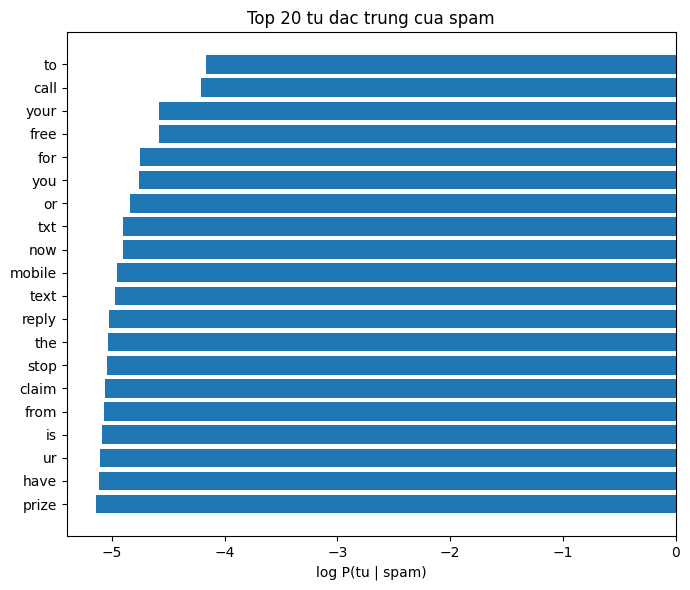

In [9]:
vectorizer = best_model.named_steps["tfidfvectorizer"]
nb = best_model.named_steps["multinomialnb"]
feature_names = np.array(vectorizer.get_feature_names_out())
log_prob_spam = nb.feature_log_prob_[1]  # lop 1 = spam
top20_idx = np.argsort(log_prob_spam)[::-1][:20]
top20_words = feature_names[top20_idx]
print(list(top20_words))

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top20_words[::-1], log_prob_spam[top20_idx][::-1])
ax.set_xlabel("log P(tu | spam)")
ax.set_title("Top 20 tu dac trung cua spam")
fig.tight_layout()
fig.savefig("../reports/top_tu_spam.png", dpi=120)
plt.show()

Cac tu nhu "free", "txt", "claim", "prize", "call", "mobile", "reply",
"stop" deu rat hop ly - dung la nhung tu quang cao/khuyen mai/cam ket
hanh dong thuong thay trong SMS rac.

## 10. Chon nguong dat precision >= 0,98

Nguong: 0.571, precision=0.9829, recall=0.8779
[[901   2]
 [ 16 115]]


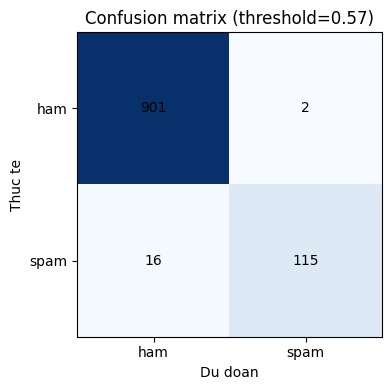

In [10]:
proba = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, proba)

target_precision = 0.98
ok = np.where(precisions[:-1] >= target_precision)[0]
if len(ok) > 0:
    chosen_idx = ok[0]
    chosen_threshold = thresholds[chosen_idx]
    print(f"Nguong: {chosen_threshold:.3f}, precision={precisions[chosen_idx]:.4f}, "
          f"recall={recalls[chosen_idx]:.4f}")
else:
    chosen_threshold = 0.5
    print("Khong tim duoc nguong dat muc tieu, dung mac dinh 0.5")

final_pred = (proba >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, final_pred)
print(cm)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["ham", "spam"])
ax.set_yticks([0, 1], ["ham", "spam"])
ax.set_xlabel("Du doan")
ax.set_ylabel("Thuc te")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
ax.set_title(f"Confusion matrix (threshold={chosen_threshold:.2f})")
fig.tight_layout()
fig.savefig("../reports/confusion_matrix.png", dpi=120)
plt.show()

## 11. Phan tich 10 tin bi phan loai sai

In [11]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
wrong_mask = final_pred != y_test_reset.values
wrong_idx = np.where(wrong_mask)[0][:10]
print(f"Tong so loi: {wrong_mask.sum()}")
for i in wrong_idx:
    thuc_te = "spam" if y_test_reset[i] == 1 else "ham"
    du_doan = "spam" if final_pred[i] == 1 else "ham"
    print(f"[thuc te={thuc_te}, du doan={du_doan}] {X_test_reset[i][:80]}")

Tong so loi: 18
[thuc te=ham, du doan=spam] K:)eng rocking in ashes:)
[thuc te=spam, du doan=ham] Thanks for the Vote. Now sing along with the stars with Karaoke on your mobile. 
[thuc te=spam, du doan=ham] Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next wee
[thuc te=spam, du doan=ham] ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8
[thuc te=spam, du doan=ham] Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin
[thuc te=spam, du doan=ham] Missed call alert. These numbers called but left no message. 07008009200
[thuc te=spam, du doan=ham] SMS. ac sun0819 posts HELLO:\You seem cool
[thuc te=spam, du doan=ham] Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rud
[thuc te=spam, du doan=ham] Check Out Choose Your Babe Videos @ sms.shsex.netUN fgkslpoPW fgkslpo
[thuc te=spam, du doan=ham] 88066 FROM 88066 LOST 3POUND HELP


Da so loi la FN (spam bi doan nham thanh ham): nhung tin spam viet kieu
"ca nhan hoa" (khong dung tu quang cao ro rang, viet tat nhieu, khong co
tu khoa nhu "free"/"prize") de danh lua ca model lan nguoi doc. Day la
danh doi chap nhan duoc vi muc tieu la precision cao, khong phai recall cao.

## 12. So sanh voi Logistic Regression + TF-IDF

In [12]:
logreg_pipe = make_pipeline(
    TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)
logreg_pipe.fit(X_train, y_train)
logreg_pred = logreg_pipe.predict(X_test)

print(f"NB   (best): precision={precision_score(y_test, best_pred):.4f}  "
      f"recall={recall_score(y_test, best_pred):.4f}  f1={f1_score(y_test, best_pred):.4f}")
print(f"LogReg     : precision={precision_score(y_test, logreg_pred):.4f}  "
      f"recall={recall_score(y_test, logreg_pred):.4f}  f1={f1_score(y_test, logreg_pred):.4f}")

NB   (best): precision=0.9746  recall=0.8779  f1=0.9237
LogReg     : precision=0.9516  recall=0.9008  f1=0.9255


Logistic Regression nhinh hon chut it ve f1/recall, nhung Naive Bayes
train nhanh hon nhieu va don gian hon de trien khai/giai thich - phu hop
lam baseline san xuat truoc khi dau tu vao model phuc tap hon.

## Thoi gian train + du doan (yeu cau < 5ms/tin)

In [13]:
t0 = time.time()
best_model.fit(X_train, y_train)
train_time = time.time() - t0

sample = [X_test.iloc[0]]
t0 = time.time()
best_model.predict(sample)
predict_time_ms = (time.time() - t0) * 1000

print(f"Thoi gian train: {train_time:.3f}s")
print(f"Thoi gian du doan 1 tin: {predict_time_ms:.3f}ms")

Thoi gian train: 0.051s
Thoi gian du doan 1 tin: 0.684ms


## Luu model

In [14]:
joblib.dump(best_model, "../models/nb_pipeline.joblib")
result_table.to_csv("../reports/bang_so_sanh.csv", index=False)
print("Da luu xong.")

Da luu xong.
